# 1BM110 - Assignment 1 - Group 7

**Students & IDs** \
Kazimir Breuer - 1574639 \
Daphne Gomes de Mesquita - 1678507 \
Isabelle Weenink - 1722239  \
Renske Quekel - 1529617

**Date** \
10th of March 2026

## Import Libraries


In [2]:
import pandas as pd
import numpy as np  
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pandas import DataFrame, concat
from sklearn.linear_model import LinearRegression

## 1. Load dataset

### 1.1 Load the data

In [3]:
# Load datasets
df   = pd.read_csv('energy_generation_train.csv')  # train set
test = pd.read_csv('energy_generation_test.csv')   # test set

# Display the first few rows of the training dataset
print("Train set:")
display(df.head())

print("Test set:")
display(test.head())

Train set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2023-01-01 00:00:00,0.0,NaN,NaN,919.0,1225.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,161.0,NaN,1.0,69.0,1893.0,807.0
1,2023-01-01 00:15:00,0.0,NaN,NaN,921.0,1235.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,70.0,1367.0,741.0
2,2023-01-01 00:30:00,0.0,NaN,NaN,922.0,1249.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,139.0,NaN,1.0,69.0,1052.0,686.0
3,2023-01-01 00:45:00,0.0,NaN,NaN,966.0,1254.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,140.0,NaN,1.0,68.0,1090.0,682.0
4,2023-01-01 01:00:00,0.0,NaN,NaN,999.0,1258.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,485.0,137.0,NaN,1.0,68.0,1082.0,760.0


Test set:


,DateTime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
0,2024-02-01 00:00:00,0.0,NaN,NaN,1795.0,950.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,185.0,NaN,0.0,69.0,3260.0,1207.0
1,2024-02-01 00:15:00,0.0,NaN,NaN,1586.0,958.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,206.0,NaN,0.0,70.0,3269.0,1199.0
2,2024-02-01 00:30:00,0.0,NaN,NaN,1349.0,1055.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,208.0,NaN,0.0,69.0,3272.0,1180.0
3,2024-02-01 00:45:00,0.0,NaN,NaN,1264.0,997.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,64.0,3275.0,1180.0
4,2024-02-01 01:00:00,0.0,NaN,NaN,1278.0,982.0,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,486.0,184.0,NaN,0.0,61.0,3277.0,1183.0


### 1.2 Ensure correct datatypes

In [4]:
# Ensure all columns have the correct data type for both sets
for dataset in [df, test]:
    dataset['DateTime'] = pd.to_datetime(dataset['DateTime'])
    numeric_cols = dataset.columns.drop('DateTime')
    dataset[numeric_cols] = dataset[numeric_cols].apply(pd.to_numeric, errors='coerce')


# Verify data types are correct now
print("Train set:")
display(pd.DataFrame({'Data Type': df.dtypes}))

print("Test set:")
display(pd.DataFrame({'Data Type': test.dtypes}))

Train set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


Test set:


,Data Type
DateTime,datetime64[us]
Biomass,float64
Fossil Brown coal/Lignite,float64
Fossil Coal-derived gas,float64
Fossil Gas,float64
Fossil Hard coal,float64
Fossil Oil,float64
Fossil Oil shale,float64
Fossil Peat,float64
Geothermal,float64


### 1.3 Keep non-renewable sources 

 

In this step, the dataset is reduced to only the columns that are relevant for the forecasting task. Specifically, the DateTime, Fossil Gas, Fossil Hard coal, and Nuclear columns are kept, while all other energy sources are removed from both the training and test datasets. The goal of the assignment is to predict the energy generated by non-renewable sources. Therefore, keeping only these variables simplifies the dataset and removes unnecessary information that are not part of the assignment. This also reduces noise and computational complexity for the model. After this step, both the training and test dataset contain only the timestamp and the three non-renewable energy generation variables. 

In [5]:
# Keep only datetime and the non-renewable energy sources

cols = ['DateTime', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear']
df   = df[cols]
test = test[cols]
print(df.head())

             DateTime  Fossil Gas  Fossil Hard coal  Nuclear
0 2023-01-01 00:00:00       919.0            1225.0    485.0
1 2023-01-01 00:15:00       921.0            1235.0    485.0
2 2023-01-01 00:30:00       922.0            1249.0    485.0
3 2023-01-01 00:45:00       966.0            1254.0    485.0
4 2023-01-01 01:00:00       999.0            1258.0    485.0


### 1.4 Display basic statistics

In [6]:
# Describe basic statistics of numerical variables
def describe_extended(dataset, name):
    num_cols = dataset.select_dtypes(include='number').columns
    stats = dataset[num_cols].describe()
    stats.loc['missing'] = dataset[num_cols].isna().sum()
    stats.loc['missing %'] = (dataset[num_cols].isna().mean() * 100).round(2)
    stats.loc['zeros'] = dataset[num_cols].eq(0).sum()
    stats.loc['zeros %'] = (dataset[num_cols].eq(0).mean() * 100).round(2)
    print(f"{name}:")
    display(stats)

describe_extended(df, "Train set")
describe_extended(test, "Test set")


Train set:


,Fossil Gas,Fossil Hard coal,Nuclear
count,36165.000000,36165.000000,36166.000000
mean,3512.526780,1362.925702,433.143837
std,2256.922636,999.446391,135.731203
min,0.000000,0.000000,0.000000
25%,1525.000000,545.000000,470.000000
50%,2874.000000,1204.000000,475.000000
75%,5263.000000,2147.000000,484.000000
max,9666.000000,3912.000000,490.000000
missing,27.000000,27.000000,26.000000
missing %,0.070000,0.070000,0.070000


Test set:


,Fossil Gas,Fossil Hard coal,Nuclear
count,33273.000000,33271.000000,33273.000000
mean,3523.873561,1239.446575,380.551198
std,2435.205330,1167.231757,192.315344
min,0.000000,0.000000,0.000000
25%,1509.000000,280.000000,466.000000
50%,2706.000000,880.000000,475.000000
75%,5148.000000,2041.000000,485.000000
max,11004.000000,3926.000000,491.000000
missing,43.000000,45.000000,43.000000
missing %,0.130000,0.140000,0.130000


## 2. Pre-processing

### 2.1 Add total energy column

A new column called Total_Energy is created for both the train and test set by summing the three non-renewable energy sources: Fossil Gas, Fossil Hard coal, and Nuclear. The goal is to predict the total amount of energy generated by non-renewable sources. Since the dataset contains these sources as separate variables, are now combined to a single variable. By doing this, the model learns patterns in the overall non-renewable energy production rather than focusing on each individual source separately. After this step, the dataset includes a new column called Total_Energy, which represents the combined energy generation from fossil gas, fossil hard coal, and nuclear sources for each timestamp. 

In [7]:
# Make total energy column by summing the three non-renewable energy sources
df['Total_Energy'] = df['Fossil Gas'] + df['Fossil Hard coal'] + df['Nuclear']
test['Total_Energy'] = test['Fossil Gas'] + test['Fossil Hard coal'] + test['Nuclear']

### 2.2 Fill missing values

Linear interpolation is applied to the non-renewable energy columns in both the training and test set. The Total_Energy column is calculated again to ensure that it reflects the updated interpolated values. The dataset is then checked if all the missing values are gone. This is needed, because missing values can cause problems for machine learning models as they require complete input. Linear interpolation is a good method for time series because it estimates missing values based on the values before and after the missing observation, while keeping the general trend of the data the same. After this step, the dataset contains no missing values anymore in the columns. Furthermore, the Total_Energy column is updated so that it correctly reflects the corrected energy values.

In [8]:

# Interpolate missing values for non-renewable sources
energy_cols = ['Fossil Gas', 'Fossil Hard coal', 'Nuclear']
for dataset in [df, test]:
    dataset[energy_cols] = dataset[energy_cols].interpolate(method='linear')

# Recalculate Total_Energy based on interpolated values
df['Total_Energy']   = df['Fossil Gas']   + df['Fossil Hard coal']   + df['Nuclear']
test['Total_Energy'] = test['Fossil Gas'] + test['Fossil Hard coal'] + test['Nuclear']

print("Train set - missing values per column:")
print(df.isnull().sum())

print("\nTest set - missing values per column:")
print(test.isnull().sum())



Train set - missing values per column:
DateTime            0
Fossil Gas          0
Fossil Hard coal    0
Nuclear             0
Total_Energy        0
dtype: int64

Test set - missing values per column:
DateTime            0
Fossil Gas          0
Fossil Hard coal    0
Nuclear             0
Total_Energy        0
dtype: int64


### 2.3 Checking for outliers using a boxplot




A boxplot is created for the non-renewable energy variables to visualize the distribution of the data and detect potential extreme values. This is done, because checking for outliers helps identify whether the dataset contains unusual values that could negatively affect the model. Visualizing the data makes it possible to quickly see whether the data contains possible errors or unrealistic observations. The boxplot shows the spread of the non-renewable energy values and highlights potential extreme values. These values are kept in the dataset because they likely represent real fluctuations in energy production rather than errors.

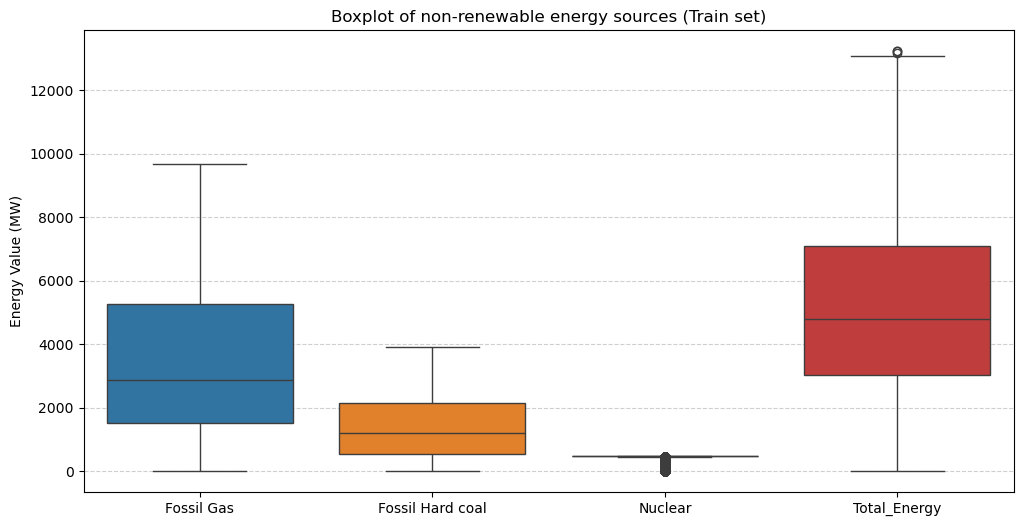

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['DateTime']))
plt.title('Boxplot of non-renewable energy sources (Train set)')
plt.ylabel('Energy Value (MW)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### 2.4 Visualizing Energy Generation Over Time

Time series plots are created for the three non-renewable energy sources in both the training and test datasets. Each energy source is plotted against the DateTime variable using separate subplots to visualize how energy generation evolves over time.
Visualizing the time series helps to better understand the structure and behavior of the data. It makes it able to observe patterns such as trends, fluctuations in the data. This step also helps to verify that both the training and test datasets follow similar patterns. The plots provide a clear overview of how each non-renewable energy source changes over time in both datasets. 

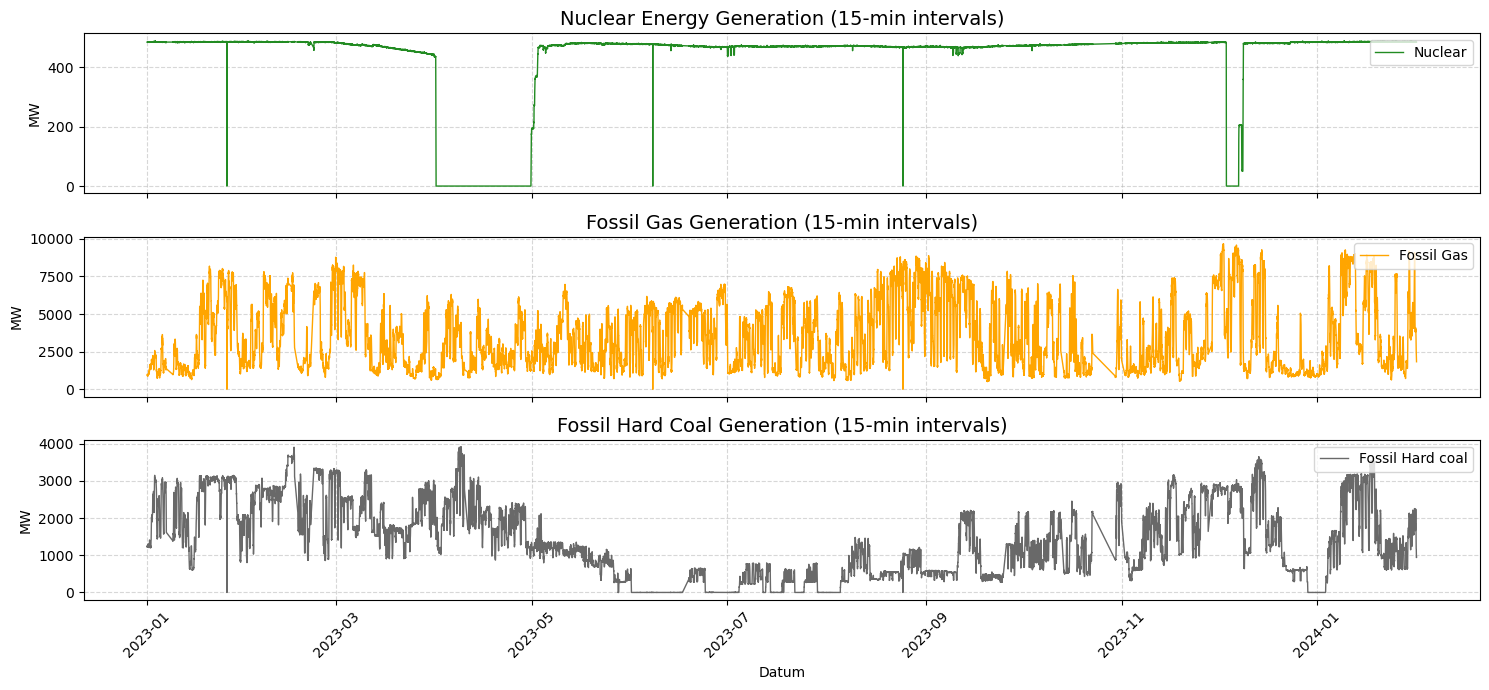

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 7), sharex=True)

# 1. Nuclear Energy 
ax1.plot(df['DateTime'], df['Nuclear'], color='forestgreen', linewidth=1, label='Nuclear')
ax1.set_title('Nuclear Energy Generation (15-min intervals)', fontsize=14)
ax1.set_ylabel('MW')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# 2. Fossil Gas
ax2.plot(df['DateTime'], df['Fossil Gas'], color='orange', linewidth=1, label='Fossil Gas')
ax2.set_title('Fossil Gas Generation (15-min intervals)', fontsize=14)
ax2.set_ylabel('MW')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# 3. Fossil Hard coal
ax3.plot(df['DateTime'], df['Fossil Hard coal'], color='dimgray', linewidth=1, label='Fossil Hard coal')
ax3.set_title('Fossil Hard Coal Generation (15-min intervals)', fontsize=14)
ax3.set_ylabel('MW')
ax3.set_xlabel('Datum')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

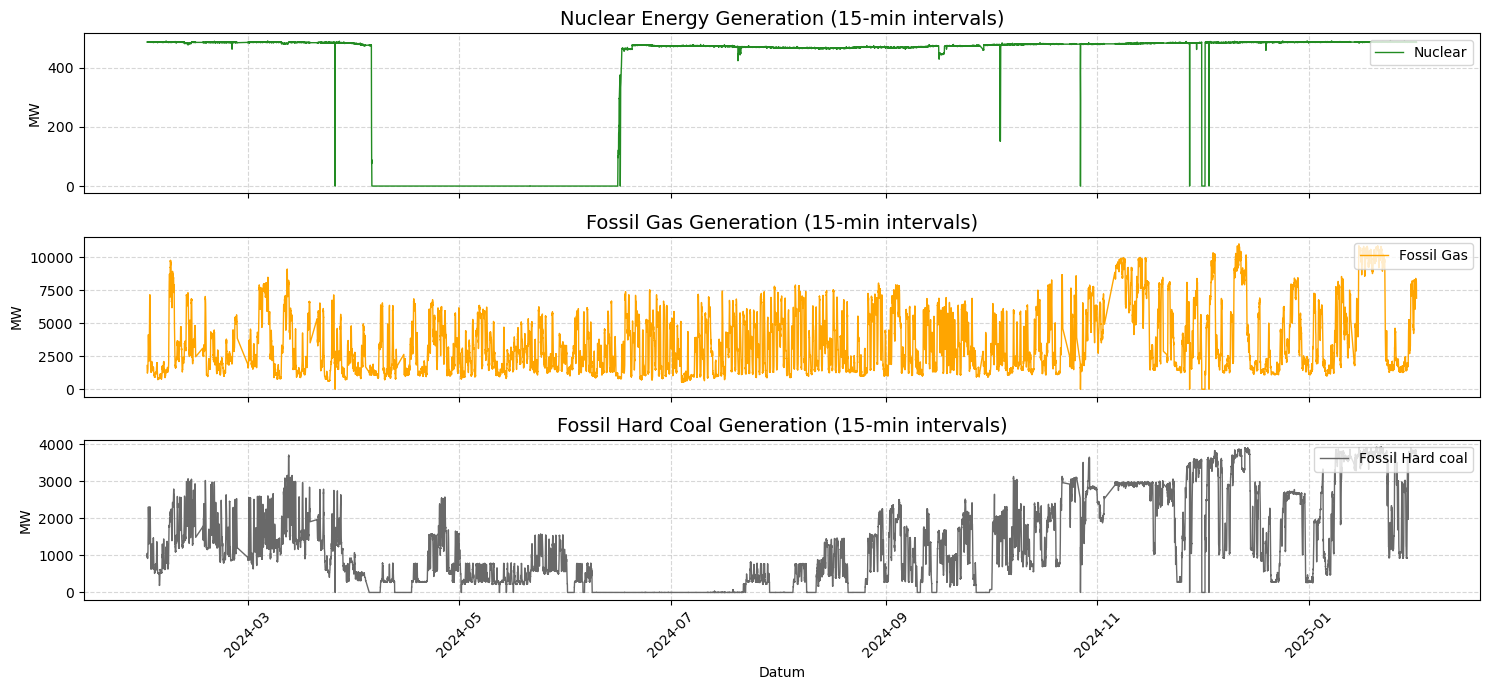

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 7), sharex=True)

# 1. Nuclear Energy 
ax1.plot(test['DateTime'], test['Nuclear'], color='forestgreen', linewidth=1, label='Nuclear')
ax1.set_title('Nuclear Energy Generation (15-min intervals)', fontsize=14)
ax1.set_ylabel('MW')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# 2. Fossil Gas
ax2.plot(test['DateTime'], test['Fossil Gas'], color='orange', linewidth=1, label='Fossil Gas')
ax2.set_title('Fossil Gas Generation (15-min intervals)', fontsize=14)
ax2.set_ylabel('MW')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# 3. Fossil Hard coal
ax3.plot(test['DateTime'], test['Fossil Hard coal'], color='dimgray', linewidth=1, label='Fossil Hard coal')
ax3.set_title('Fossil Hard Coal Generation (15-min intervals)', fontsize=14)
ax3.set_ylabel('MW')
ax3.set_xlabel('Datum')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right')


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Organize time-dependent data

Because the dataset is time series data, it is important that the observations follow a consistent and complete time structure. First, duplicate timestamps are removed so that each moment in time appears only once in the dataset. Next, the dataset is checked for missing timestamps. Since the data should be recorded every 15 minutes, a complete sequence of timestamps is created between the minimum and maximum time values. If timestamps are missing, they are added and the corresponding energy values are estimated using linear interpolation. This ensures that the time series remains continuous, which is important for models such as LSTMs that learn patterns over time. Finally, the data is aggregated from 15-minute intervals to daily values by summing the energy production for each day. This transformation is necessary as the goal is to predict daily energy generation and not every 15 minutes. In this way, the dataset becomes a clean and structured daily time series that can be used as input for the forecasting model.


### 3.1 Remove duplicate timestamps

In [12]:
# Remove duplicate timestamps (keep first occurrence)
def remove_duplicate_timestamps(dataset, label):
    n_before = len(dataset)
    cleaned = (dataset
               .drop_duplicates(subset='DateTime', keep='first')
               .sort_values('DateTime')
               .reset_index(drop=True))
    n_removed = n_before - len(cleaned)
    print(f"[{label}] Duplicate timestamps removed: {n_removed}  ({n_before} → {len(cleaned)} rows)")
    return cleaned

df   = remove_duplicate_timestamps(df,   "Train")
test = remove_duplicate_timestamps(test, "Test")

[Train] Duplicate timestamps removed: 0  (36192 → 36192 rows)
[Test] Duplicate timestamps removed: 4  (33316 → 33312 rows)


### 3.2 Complete timestamps
First the duplicate timestamps are removed. Second, the missing timestamps are checked. The missing timestamps are added and the values are caclulated by performing linear interpolation. 

In [13]:

# Add missing timestamps (fill gaps with linear interpolation, every 15 minutes)
def add_missing_timestamps(dataset, label):
    full_range = pd.date_range(start=dataset['DateTime'].min(),
                               end=dataset['DateTime'].max(),
                               freq='15min')
    n_original = len(dataset)
    n_expected = len(full_range)
    n_added    = n_expected - n_original

    dataset = (dataset
               .set_index('DateTime')
               .reindex(full_range)
               .rename_axis('DateTime')
               .interpolate(method='linear')
               .reset_index())

    print(f"[{label}] Missing timestamps added: {n_added}  ({n_original} → {n_expected} rows)")
    return dataset

df   = add_missing_timestamps(df,   "Train")
test = add_missing_timestamps(test, "Test")


[Train] Missing timestamps added: 1824  (36192 → 38016 rows)
[Test] Missing timestamps added: 1824  (33312 → 35136 rows)


### 3.3 Group by day

In [14]:
df_daily = df.set_index('DateTime').resample('D').sum()
test_daily = test.set_index('DateTime').resample('D').sum()

df_daily = df_daily.reset_index()
test_daily = test_daily.reset_index()

print("Daily totals (Train set):")
print(df_daily.head())

print("Daily totals (Test set):")
print(test_daily.head())

Daily totals (Train set):
    DateTime  Fossil Gas  Fossil Hard coal  Nuclear  Total_Energy
0 2023-01-01    108651.0          120822.0  46548.0      276021.0
1 2023-01-02    173299.0          187232.0  46599.0      407130.0
2 2023-01-03    182228.0          265139.0  46598.0      493965.0
3 2023-01-04     94086.0          192753.0  46574.0      333413.0
4 2023-01-05    206362.0          231197.0  46571.0      484130.0
Daily totals (Test set):
    DateTime  Fossil Gas  Fossil Hard coal  Nuclear  Total_Energy
0 2024-02-01    332127.0          156795.0  46697.0      535619.0
1 2024-02-02    147865.0           94164.0  46645.0      288674.0
2 2024-02-03    121804.0           71619.0  46654.0      240077.0
3 2024-02-04     83696.0           46602.0  46650.0      176948.0
4 2024-02-05    139952.0           83485.0  46622.0      270059.0


## 4. Prepare data or model selection and evaluation

### 4.1 Transform data (normalization)

The numerical variables are normalized using a Min-Max scaling approach. This transformation rescales all numerical features to a range between 0 and 1. It is important for NN models such as LSTMs, because large differences in the scale of variables can make training unstable. By normalizing the features, the model can learn more efficiently and training becomes more stable.
The scaler is fitted only on the training dataset. This prevents information of the test data from leaking into the training process. That makes it a better evaluation of the model.

Then, the time data is transformed into a supervised learning format. The previous 'n' days are used as input features to predict the next day’s energy generation. Different number of previous n days are tested to determine how many provide the most useful information for forecasting.

To identify possible number of previous days, a linear regression model is used. Several number of days are evaluated and their prediction errors are compared using RMSE and MAE. 

In [15]:
# Scale/normalize features (fit on train, apply to both)
df_final = df_daily.copy()
test_final = test_daily.copy()

scaler = MinMaxScaler(feature_range=(0, 1))
numeric_cols = df_final.select_dtypes(include=['number']).columns

df_final[numeric_cols] = scaler.fit_transform(df_final[numeric_cols])
test_final[numeric_cols] = scaler.transform(test_final[numeric_cols])  # transform only, no re-fit

print("Train set statistics:")
print(df_final[numeric_cols].describe().loc[['min', 'max']])

print("\nTest set statistics:")
print(test_final[numeric_cols].describe().loc[['min', 'max']])

Train set statistics:
     Fossil Gas  Fossil Hard coal  Nuclear  Total_Energy
min         0.0               0.0      0.0           0.0
max         1.0               1.0      1.0           1.0

Test set statistics:
     Fossil Gas  Fossil Hard coal   Nuclear  Total_Energy
min   -0.081208          0.000000  0.000000     -0.101418
max    1.230619          1.043883  0.999722      1.271139


--- Optimization Results (Validation on Train Set) ---
    Days    RMSE     MAE
0      1  0.1979  0.1649
1      2  0.1949  0.1598
2      3  0.1938  0.1593
3      4  0.1927  0.1563
4      5  0.1929  0.1572
5      6  0.1962  0.1604
6      7  0.1996  0.1628
7      8  0.1945  0.1589
8      9  0.2015  0.1639
9     10  0.2044  0.1684
10    11  0.2025  0.1637
11    12  0.2029  0.1646
12    15  0.2075  0.1704
13    20  0.2183  0.1798
14    28  0.2312  0.1931


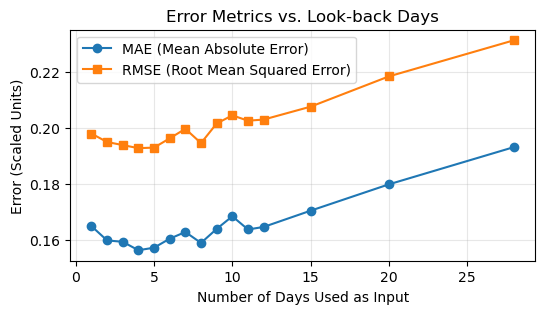

In [16]:
# 1. Define the transformation function
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = data.shape[1]
    df = pd.DataFrame(data)
    cols, names = [], []
    
    # Input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    
    # Forecast sequence (t, t+1, ... t+n)
    # We predict 'Total_Energy' (assumed to be the first column at index 0)
    for i in range(0, n_out):
        cols.append(df[0].shift(-i))
        if i == 0:
            names += [('var1(t)')]
        else:
            names += [('var1(t+%d)' % (i))]
    
    agg = concat(cols, axis=1)
    agg.columns = names
    
    if dropnan:
        agg.dropna(inplace=True)
    
    return agg

# 2. Prepare data from your already scaled df_final
# Ensure 'Total_Energy' is the first column for the function to pick it as target
cols_ordered = ['Total_Energy', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear']
train_values = df_final[cols_ordered].values

results = []
days_to_test = [1, 2, 3, 4, 5,6, 7, 8,9,10,11,12,15, 20, 28]

# 3. Loop to test different look-back periods (n_in)
for d in days_to_test:
    # Reframe the data
    reframed = series_to_supervised(train_values, n_in=d, n_out=1)
    
    # Time-series split: use 80% of train_values for training, 20% for validation
    data_values = reframed.values
    split_idx = int(len(data_values) * 0.8)
    train_data, val_data = data_values[:split_idx, :], data_values[split_idx:, :]
    
    # Split into X (history) and y (target today)
    X_train, y_train = train_data[:, :-1], train_data[:, -1]
    X_val, y_val = val_data[:, :-1], val_data[:, -1]
    
    # Fit Baseline Model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict and calculate errors
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    results.append({"Days": d, "RMSE": round(rmse, 4), "MAE": round(mae, 4)})

df_performance = pd.DataFrame(results)
print("--- Optimization Results (Validation on Train Set) ---")
print(df_performance)

plt.figure(figsize=(6, 3))
plt.plot(df_performance['Days'], df_performance['MAE'], marker='o', label='MAE (Mean Absolute Error)')
plt.plot(df_performance['Days'], df_performance['RMSE'], marker='s', label='RMSE (Root Mean Squared Error)')
plt.title('Error Metrics vs. Look-back Days')
plt.xlabel('Number of Days Used as Input')
plt.ylabel('Error (Scaled Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4.2 Split Data
To evaluate the forecasting model, the dataset is split into training and validation sets. Because the data represents a time series, the split is performed chronologically. Random splitting would break the temporal structure of the data.

hold out validation strategy
Training vs. Validation: The training set is used to optimize the LSTM weights, while the validation set (Jan 2024) is used to tune hyperparameters (like the learning rate and units) and find the optimal stopping epoch.

Out-of-Sample Testing: The test set serves as a proxy for "real world" performance. We only run our finalized model (with 21 epochs and 32 units) on this data once.




In [17]:
val_days = 31 # Januari 2024
train_df = df_final.iloc[:-val_days]
val_df   = df_final.iloc[-val_days:]

#print(val_df.head(5))
#print(train_df)

### 4.3 Visualization of set up

To show the evaluation strategy, a visualization is created that shows the time periods corresponding to the training, validation, and test datasets. This plot shows how the data is split over time. This helps to verify that the dataset is divided correct. It shows furthermore that the test sets occur after the training data, which is important as the model should only learn from information from the past.

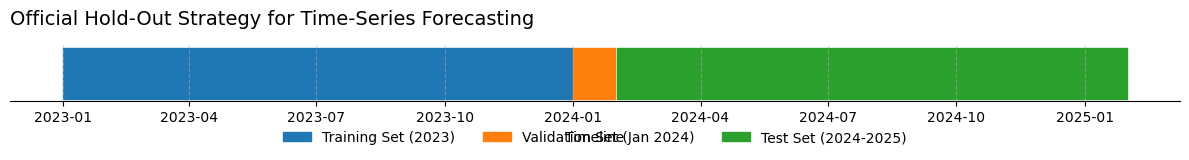

In [18]:
# 1. Define the splitting points (as dummy dates for the plot)
# Training: 12 months, Val: 1 month, Test: 12 months
dates = pd.date_range(start='2023-01-01', end='2025-01-31', freq='D')

# Create a 'Fold' array to color the data
# 0 = Train, 1 = Val, 2 = Test
fold = []
for d in dates:
    if d < pd.Timestamp('2024-01-01'):
        fold.append(0)
    elif d < pd.Timestamp('2024-02-01'):
        fold.append(1)
    else:
        fold.append(2)

# 2. Plotting
plt.figure(figsize=(12, 2))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = ['Training Set (2023)', 'Validation Set (Jan 2024)', 'Test Set (2024-2025)']

for i in range(3):
    mask = [f == i for f in fold]
    plt.fill_between(dates[mask], 0, 1, color=colors[i], label=labels[i])

# 3. Formatting
plt.title('Official Hold-Out Strategy for Time-Series Forecasting', fontsize=14, loc='left', pad=15)
plt.yticks([]) # Hide Y-axis
plt.xlabel('Timeline', fontsize=10)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=False)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Removing spines for a cleaner 'academic' look
for spine in ['top', 'left', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import pandas as pd

# 1. Settings (Optimal look-back found: 4 days)
n_in = 4 
n_out = 1 
batch_size = 1 
target_col = 'Total_Energy'
feature_cols = ['Total_Energy', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear']

# 2. Function to create generators
def create_generator(dataset, n_in, batch_size):
    features = dataset[feature_cols].values
    target = dataset[target_col].values
    return TimeseriesGenerator(features, target, length=n_in, batch_size=batch_size)

# 3. Create all THREE generators
train_generator = create_generator(train_df, n_in, batch_size)
val_generator   = create_generator(val_df, n_in, batch_size)
test_generator  = create_generator(test_final, n_in, batch_size)

# --- OUTPUT TRAIN GENERATOR ---
print(f"--- Check Train: First 3 batches (n_in={n_in}) ---")
train_demo = []
for i in range(min(3, len(train_generator))): 
    x_batch, y_batch = train_generator[i]
    train_demo.append({
        "Batch Index": i,
        "Input (X) Shape": x_batch.shape,
        "Target (y) Waarde": y_batch[0]
    })
print(pd.DataFrame(train_demo))
print("\n--- Detail of the first Input (X) matrix (Train) ---")
print(train_generator[0][0][0])

# --- OUTPUT VALIDATION GENERATOR ---
print(f"\n--- Check Validation: First 3 batches (n_in={n_in}) ---")
val_demo = []
for i in range(min(3, len(val_generator))):
    x_batch, y_batch = val_generator[i]
    val_demo.append({
        "Batch Index": i,
        "Input (X) Shape": x_batch.shape,
        "Target (y) Waarde": y_batch[0]
    })
print(pd.DataFrame(val_demo))
print("\n--- Detail of the first Input (X) matrix (Validation) ---")
print(val_generator[0][0][0])


# --- OUTPUT TEST GENERATOR ---
print(f"\n--- Check Test: First 3 batches (n_in={n_in}) ---")
test_demo = []
for i in range(min(3, len(test_generator))):
    x_batch, y_batch = test_generator[i]
    test_demo.append({
        "Batch Index": i,
        "Input (X) Shape": x_batch.shape,
        "Target (y) Waarde": y_batch[0]
    })
print(pd.DataFrame(test_demo))
print("\n--- Detail of the first Input (X) matrix (Test) ---")
print(test_generator[0][0][0])

# 4. Totaal overzicht
print("\n--- Overzicht Aantal Batches ---")
print(f"Train batches: {len(train_generator)}")
print(f"Val batches:   {len(val_generator)}")
print(f"Test batches:  {len(test_generator)}")

--- Check Train: First 3 batches (n_in=4) ---
   Batch Index Input (X) Shape  Target (y) Waarde
0            0       (1, 4, 4)           0.349715
1            1       (1, 4, 4)           0.288530
2            2       (1, 4, 4)           0.184865

--- Detail of the first Input (X) matrix (Train) ---
[[0.14286879 0.04966548 0.34463594 0.99653179]
 [0.27318222 0.13545884 0.53406562 0.99762364]
 [0.35949031 0.14730837 0.75628966 0.99760223]
 [0.19991253 0.03033649 0.54981387 0.99708842]]

--- Check Validation: First 3 batches (n_in=4) ---
   Batch Index Input (X) Shape  Target (y) Waarde
0            0       (1, 4, 4)           0.444341
1            1       (1, 4, 4)           0.377802
2            2       (1, 4, 4)           0.292727

--- Detail of the first Input (X) matrix (Validation) ---
[[1.09859309e-02 3.38625525e-02 4.27864060e-05 9.97109827e-01]
 [6.97829749e-02 1.12368892e-01 0.00000000e+00 9.97409548e-01]
 [8.54602651e-02 1.17190190e-01 3.48053151e-02 9.96082209e-01]
 [4.6985851

## 5. RNN architecture

In [20]:
batch_size_train = 16 
train_generator = create_generator(train_df, n_in=4, batch_size=batch_size_train)
val_generator   = create_generator(val_df, n_in=4, batch_size=batch_size_train)
test_generator  = create_generator(test_final, n_in=4, batch_size=batch_size_train)

### 5.1 Hyperparameter Tuning

In [21]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

unit_options = [16, 32, 64, 128]
lr_options = [0.01, 0.005, 0.001, 0.0001]

n_in = 4      
n_features = 4 

tuning_results = []
print("Start Hyperparameter Tuning...\n")

# --- 2. De Test Loop ---
for units in unit_options:
    for lr in lr_options:
        print(f"Testen: Units={units}, Learning Rate={lr}")
        
        # Bouw een tijdelijk model voor deze specifieke test
        model = Sequential()
        model.add(Input(shape=(n_in, n_features))) 
        model.add(LSTM(units=units, activation='relu'))
        model.add(Dropout(0.2)) # Vaste dropout voor eerlijke vergelijking
        model.add(Dense(1))
        
        # Compileer het model
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
        
        # Train het model met jouw kant-en-klare data (train_df en val_df)
        history = model.fit(train_generator, validation_data=val_generator, epochs=15, verbose=0)
        
        # Sla de laagste (beste) validatiefout op van deze testronde
        best_val_loss = min(history.history['val_loss'])
        
        tuning_results.append({
            "Units": units,
            "Learning Rate": lr,
            "Best Val Loss (MSE)": best_val_loss
        })

df_tuning = pd.DataFrame(tuning_results)
df_tuning = df_tuning.sort_values(by="Best Val Loss (MSE)")
print("\n--- Tuning Resultaten ---")
print(df_tuning)

Start Hyperparameter Tuning...

Testen: Units=16, Learning Rate=0.01


c:\Users\20213122\.conda\envs\1bm110\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Testen: Units=16, Learning Rate=0.005
Testen: Units=16, Learning Rate=0.001
Testen: Units=16, Learning Rate=0.0001
Testen: Units=32, Learning Rate=0.01
Testen: Units=32, Learning Rate=0.005
Testen: Units=32, Learning Rate=0.001
Testen: Units=32, Learning Rate=0.0001
Testen: Units=64, Learning Rate=0.01
Testen: Units=64, Learning Rate=0.005
Testen: Units=64, Learning Rate=0.001
Testen: Units=64, Learning Rate=0.0001
Testen: Units=128, Learning Rate=0.01
Testen: Units=128, Learning Rate=0.005
Testen: Units=128, Learning Rate=0.001
Testen: Units=128, Learning Rate=0.0001

--- Tuning Resultaten ---
    Units  Learning Rate  Best Val Loss (MSE)
4      32         0.0100             0.039331
0      16         0.0100             0.039556
13    128         0.0050             0.039565
9      64         0.0050             0.040110
5      32         0.0050             0.040516
8      64         0.0100             0.041039
1      16         0.0050             0.042638
12    128         0.0100      

Hoewel 128 wiskundig "gewonnen" heeft, is het verschil met de 32 units microscopisch klein (0.000074). Een goede Data Scientist kiest in dit geval ALTIJD voor de 32 units.
Waarom? Een model met 128 units is 4 keer zo zwaar en complex als een model met 32 units. Als een simpel model (32) exact even goed presteert als een zwaar model (128), kies je de simpele om het risico op overfitting te verkleinen!

## 6. Training and validation losses

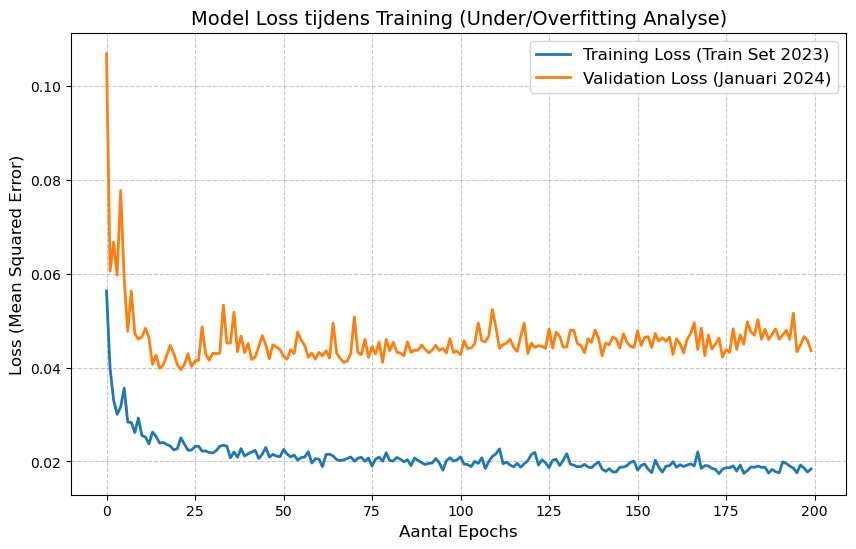

In [22]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# --- 1. Bouw het definitieve model met jouw winnende getallen ---
final_model = Sequential()
final_model.add(Input(shape=(4, 4))) # n_in=4, n_features=4
final_model.add(LSTM(units=32, activation='relu')) # Jouw geoptimaliseerde units
final_model.add(Dropout(0.2))
final_model.add(Dense(1))

# Compileer met jouw geoptimaliseerde learning rate
final_model.compile(optimizer=Adam(learning_rate=0.005), loss='mse', metrics=['mae'])

history_final = final_model.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=200, 
    verbose=0 
)\

plt.figure(figsize=(10, 6))
plt.plot(history_final.history['loss'], label='Training Loss (Train Set 2023)', linewidth=2)
plt.plot(history_final.history['val_loss'], label='Validation Loss (Januari 2024)', linewidth=2)
plt.title('Model Loss tijdens Training (Under/Overfitting Analyse)', fontsize=14)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.xlabel('Aantal Epochs', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Find lowest Epoch

In [23]:
val_losses = history_final.history['val_loss']
# Zoek de allerlaagste waarde in die lijst
lowest_val_loss = min(val_losses)
optimal_epoch = val_losses.index(lowest_val_loss) + 1
print(f"The lowest validation loss is: {lowest_val_loss:.5f}")
print(f"This is reached in epoch: {optimal_epoch}")

The lowest validation loss is: 0.03957
This is reached in epoch: 22


## 7. Evaluation model performance

In [24]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. BUILD AND TRAIN THE FINAL MODEL ---
print("Building and training the final model (21 epochs)...")
examen_model = Sequential()
examen_model.add(Input(shape=(4, 4))) # n_in=4, n_features=4
examen_model.add(LSTM(units=32, activation='tanh')) 
examen_model.add(Dropout(0.2))
examen_model.add(Dense(1))

examen_model.compile(optimizer=Adam(learning_rate=0.005), loss='mse')

# Train the model
examen_model.fit(train_generator, epochs=21, verbose=0)
print("Training complete!")

# --- 2. PREDICT ON THE TEST SET ---
print("Generating predictions for the test set...")
predictions_scaled = examen_model.predict(test_generator)

# --- 3. INVERSE TRANSFORM (Scale back to Megawatts) ---
# Extract the actual scaled target values from the test generator
actuals_scaled = np.concatenate([y for x, y in test_generator])

# Create dummy matrices for inverse transformation (scaler expects 4 columns)
pred_matrix = np.zeros((len(predictions_scaled), 4))
pred_matrix[:, 0] = predictions_scaled[:, 0]

actual_matrix = np.zeros((len(actuals_scaled), 4))
actual_matrix[:, 0] = actuals_scaled

# Transform back to true MW values
predictions_mw = scaler.inverse_transform(pred_matrix)[:, 0]
actuals_mw = scaler.inverse_transform(actual_matrix)[:, 0]

# --- 4. CALCULATE EVALUATION METRICS ---
mae = mean_absolute_error(actuals_mw, predictions_mw)
mse = mean_squared_error(actuals_mw, predictions_mw)
rmse = np.sqrt(mse)
r2 = r2_score(actuals_mw, predictions_mw)

print("\n--- Model Evaluation Scores (Test Set) ---")
print(f"Mean Absolute Error (MAE):     {mae:.2f} MW")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MW")
print(f"R-squared (R2) Score:           {r2:.4f}")

Building and training the final model (21 epochs)...
Training complete!
Generating predictions for the test set...


c:\Users\20213122\.conda\envs\1bm110\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


KeyboardInterrupt: 

## 8. Plot model predictions vs. test set

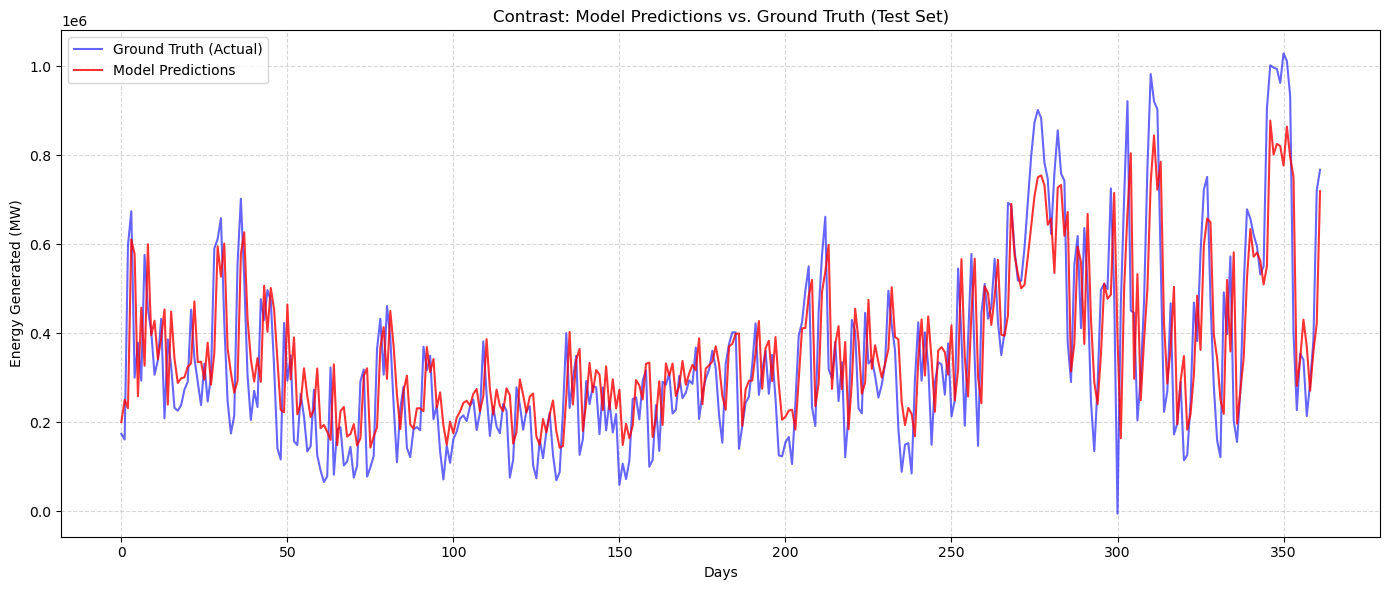

In [ ]:
import matplotlib.pyplot as plt

# --- 1. FINAL EVALUATION AND PLOTTING ---
plt.figure(figsize=(14, 6))

# Plotting the Ground Truth (Actual Values)
plt.plot(actuals_mw, label='Ground Truth (Actual)', color='blue', alpha=0.6)

# Plotting the Model Predictions
plt.plot(predictions_mw, label='Model Predictions', color='red', alpha=0.8, linewidth=1.5)

# Adding basic labels and title as per requirements
plt.title('Contrast: Model Predictions vs. Ground Truth (Test Set)')
plt.xlabel('Days')
plt.ylabel('Energy Generated (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()